#**Name :- Vitan Shukla**

#**MPOnline Application ID :- IN26013007**

#**College Name :- VIT Bhopal University**

#**College Reg. No. :- 23MIM10161**

# **Customer Churn Prediction for a Subscription Streaming Service**

## Objective

The objective of this project is to build machine learning models that predict customer churn using customer demographics, billing information, and service usage patterns. The notebook includes:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature Selection
- Model Training
- Cross Validation
- Hyperparameter Tuning
- Model Evaluation
- Business Recommendations

## Dataset Source

**Dataset Name:** Telco Customer Churn

**Source:** IBM Sample Data (Kaggle)

**Author/Uploader:** blastchar

**Version:** Latest version available on Kaggle at the time of download.

**URL:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Downloaded Using:**

```python
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

In [1]:
!pip install -q kagglehub

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset downloaded to:")
print(path)

100%|████████████████████████████████████████████████████████████████████████████████| 172k/172k [00:00<00:00, 223kB/s]

Extracting files...
Dataset downloaded to:
C:\Users\Vitan\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [4]:
import os

files = os.listdir(path)

print(files)

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
csv_path = os.path.join(
    path,
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df = pd.read_csv(csv_path)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7043
Columns : 21


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

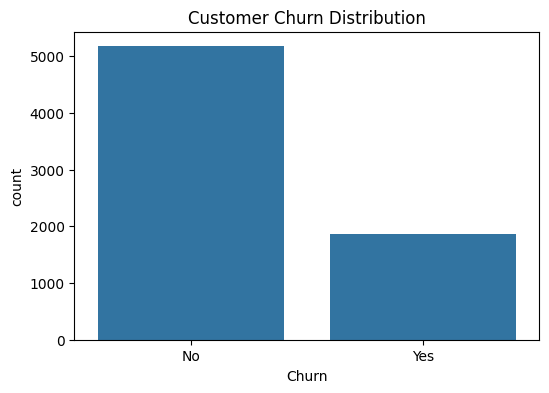

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.show()

In [15]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

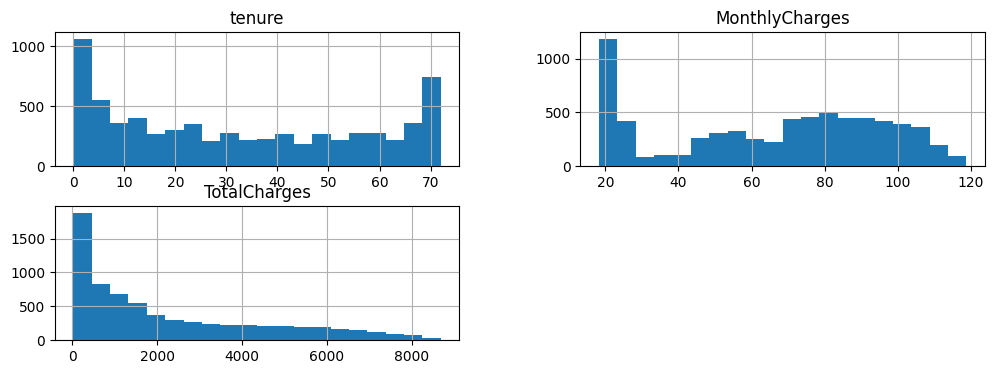

In [16]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_columns].hist(
    figsize=(12,4),
    bins=20
)

plt.show()

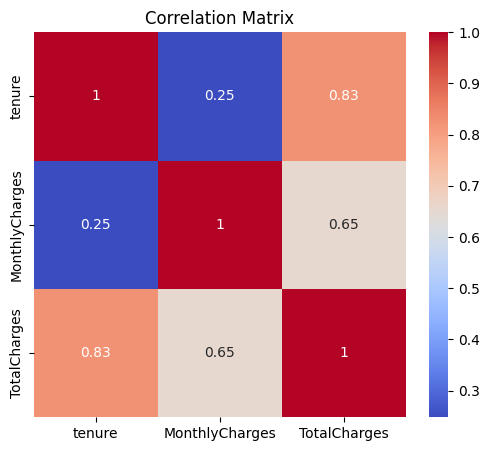

In [17]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

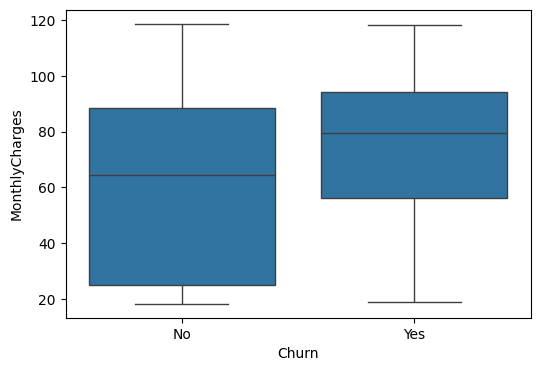

In [18]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.show()

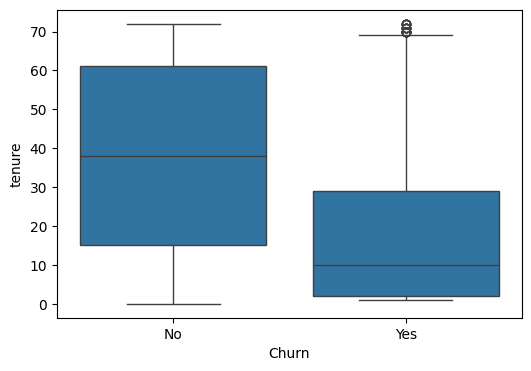

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.show()

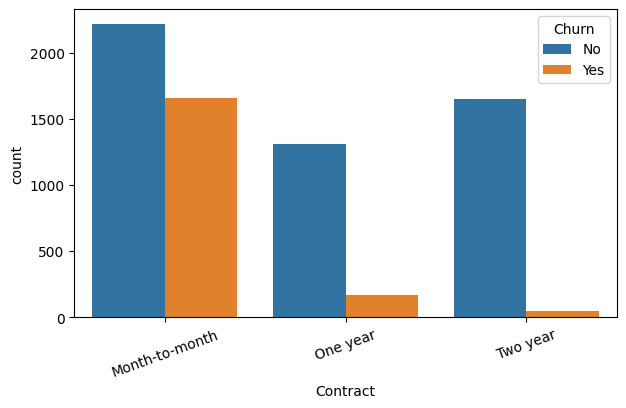

In [20]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.xticks(rotation=20)

plt.show()

In [21]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

In [22]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [23]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [24]:
categorical_features = X.select_dtypes(
    include="object"
).columns

numerical_features = X.select_dtypes(
    exclude="object"
).columns

print(categorical_features)

print(numerical_features)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [25]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [26]:
X_processed = preprocessor.fit_transform(X)

In [27]:
feature_names = preprocessor.get_feature_names_out()

X_processed = pd.DataFrame(
    X_processed,
    columns=feature_names
)

X_processed.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.439916,-1.277445,-1.160323,-0.994242,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.439916,0.066327,-0.259629,-0.173244,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.439916,-1.236724,-0.362660,-0.959674,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.439916,0.514251,-0.746535,-0.194766,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-0.439916,-1.236724,0.197365,-0.940470,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [28]:
print("Processed Feature Matrix Shape:", X_processed.shape)
print("Target Shape:", y.shape)

Processed Feature Matrix Shape: (7043, 45)
Target Shape: (7043,)


In [29]:
X_processed.to_csv(
    "processed_features.csv",
    index=False
)

y.to_csv(
    "target.csv",
    index=False
)

# **Feature Selection**

Feature selection helps improve model performance by removing redundant or less informative features.

In this section, we will apply two feature selection techniques:

1. Correlation Filtering
2. Recursive Feature Elimination (RFE)

The selected feature subsets will later be used to train and compare multiple machine learning models.

In [30]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
print("Original Number of Features:", X_processed.shape[1])

Original Number of Features: 45


In [32]:
corr_matrix = X_processed.corr().abs()

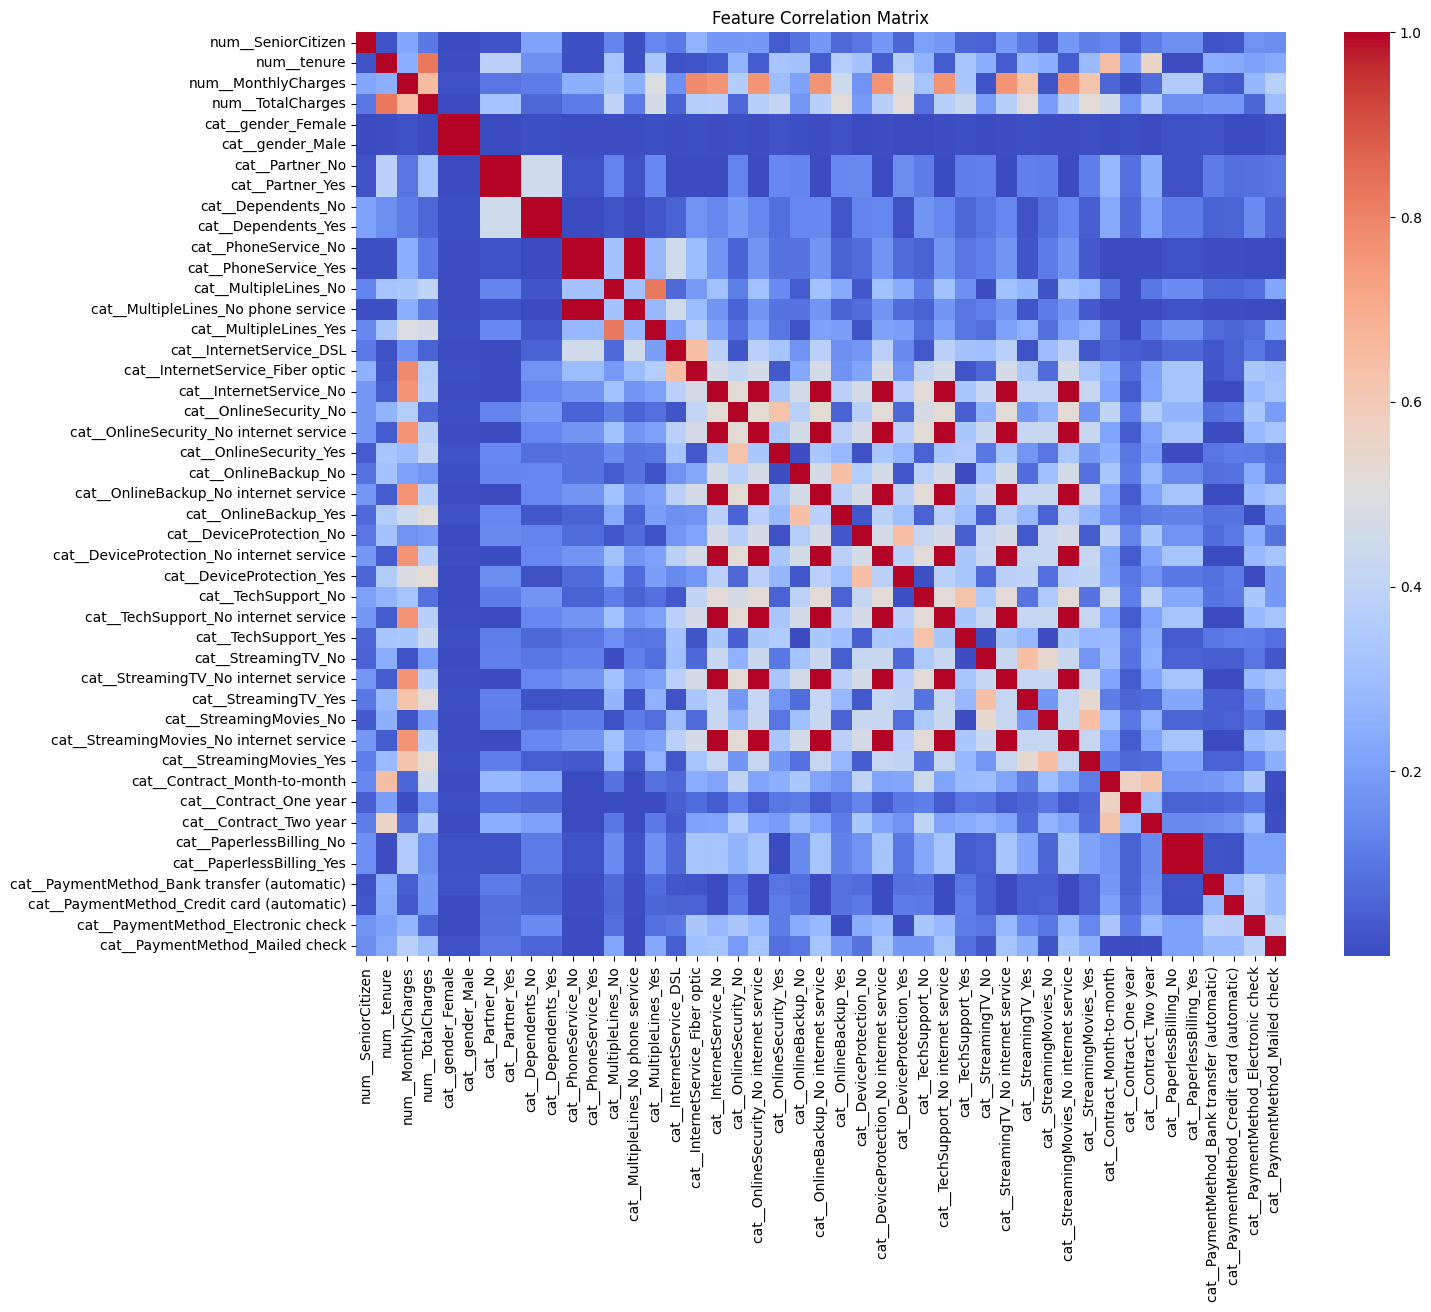

In [33]:
plt.figure(figsize=(15,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    cbar=True
)

plt.title("Feature Correlation Matrix")

plt.show()

In [34]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

In [35]:
print("Highly Correlated Features")

print("-"*50)

for feature in high_corr_features:
    print(feature)

print("\nTotal Removed:", len(high_corr_features))

Highly Correlated Features
--------------------------------------------------
cat__gender_Male
cat__Partner_Yes
cat__Dependents_Yes
cat__PhoneService_Yes
cat__MultipleLines_No phone service
cat__OnlineSecurity_No internet service
cat__OnlineBackup_No internet service
cat__DeviceProtection_No internet service
cat__TechSupport_No internet service
cat__StreamingTV_No internet service
cat__StreamingMovies_No internet service
cat__PaperlessBilling_Yes

Total Removed: 12


In [36]:
X_corr = X_processed.drop(
    columns=high_corr_features
)

In [37]:
print("Original Features :", X_processed.shape[1])

print("Correlation Features :", X_corr.shape[1])

Original Features : 45
Correlation Features : 33


In [38]:
rf_estimator = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [39]:
rfe = RFE(
    estimator=rf_estimator,
    n_features_to_select=20
)

X_rfe = rfe.fit_transform(
    X_processed,
    y
)

In [40]:
selected_features = X_processed.columns[
    rfe.support_
]

selected_features

Index(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_Yes', 'cat__Dependents_Yes', 'cat__MultipleLines_No',
       'cat__InternetService_Fiber optic', 'cat__OnlineSecurity_No',
       'cat__OnlineBackup_No', 'cat__DeviceProtection_No',
       'cat__TechSupport_No', 'cat__StreamingTV_No', 'cat__StreamingMovies_No',
       'cat__Contract_Month-to-month', 'cat__Contract_Two year',
       'cat__PaperlessBilling_No', 'cat__PaymentMethod_Electronic check'],
      dtype='object')

In [41]:
ranking = pd.DataFrame({

    "Feature": X_processed.columns,

    "Rank": rfe.ranking_

})

ranking.sort_values(
    by="Rank"
).head(30)

,Feature,Rank
0,num__SeniorCitizen,1
1,num__tenure,1
2,num__MonthlyCharges,1
3,num__TotalCharges,1
4,cat__gender_Female,1
5,cat__gender_Male,1
7,cat__Partner_Yes,1
9,cat__Dependents_Yes,1
12,cat__MultipleLines_No,1
21,cat__OnlineBackup_No,1


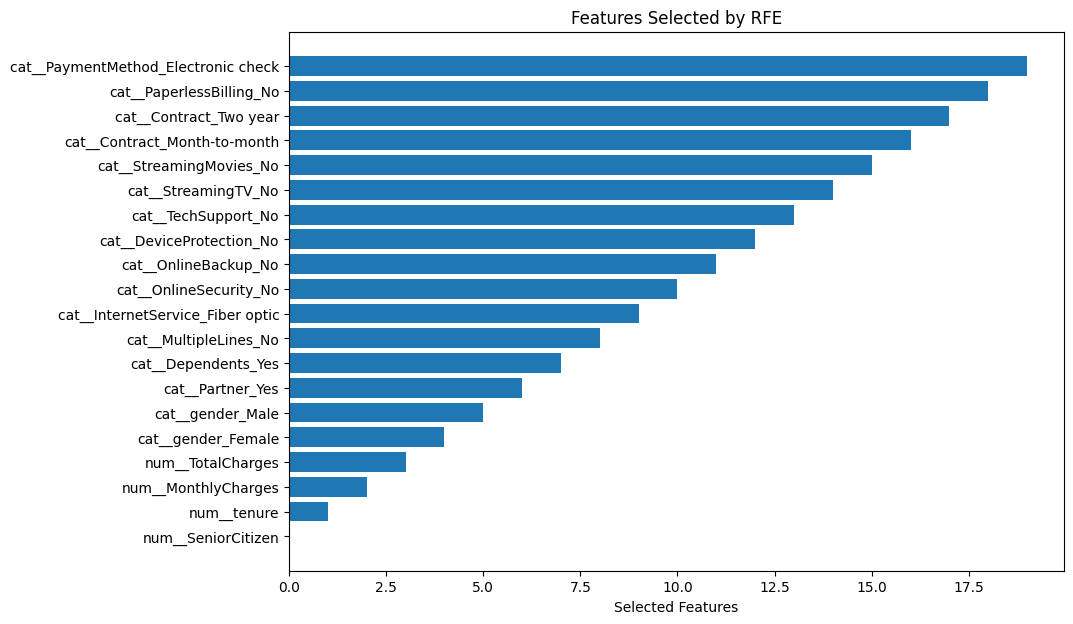

In [42]:
plt.figure(figsize=(10,7))

plt.barh(
    selected_features,
    np.arange(len(selected_features))
)

plt.title("Features Selected by RFE")

plt.xlabel("Selected Features")

plt.show()

In [43]:
X_rfe = pd.DataFrame(
    X_rfe,
    columns=selected_features
)

In [44]:
comparison = pd.DataFrame({

    "Feature Selection Method":[

        "Original",

        "Correlation Filtering",

        "Recursive Feature Elimination"

    ],

    "Number of Features":[

        X_processed.shape[1],

        X_corr.shape[1],

        X_rfe.shape[1]

    ]

})

comparison

,Feature Selection Method,Number of Features
0,Original,45
1,Correlation Filtering,33
2,Recursive Feature Elimination,20


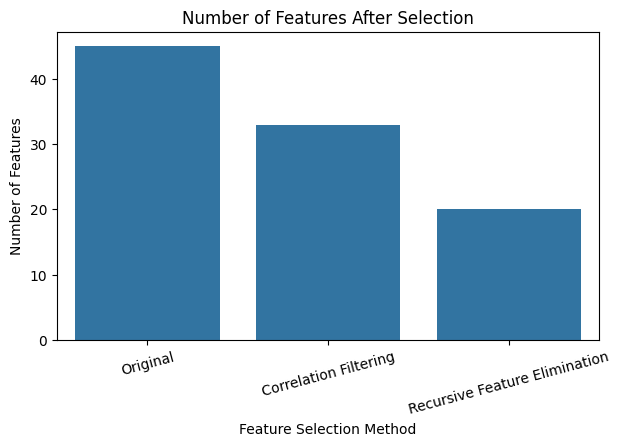

In [45]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison,
    x="Feature Selection Method",
    y="Number of Features"
)

plt.xticks(rotation=15)

plt.title("Number of Features After Selection")

plt.show()

In [46]:
X_corr.to_csv(
    "X_correlation_selected.csv",
    index=False
)

X_rfe.to_csv(
    "X_rfe_selected.csv",
    index=False
)

In [47]:
print("="*60)

print("FEATURE SELECTION SUMMARY")

print("="*60)

print(f"Original Features        : {X_processed.shape[1]}")

print(f"After Correlation Filter : {X_corr.shape[1]}")

print(f"After RFE               : {X_rfe.shape[1]}")

print("="*60)

FEATURE SELECTION SUMMARY
Original Features        : 45
After Correlation Filter : 33
After RFE               : 20


# **Model Training and Comparison**

This section compares three machine learning algorithms:

- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

Each model is trained on:

1. Full Feature Set
2. Correlation Filtered Features
3. RFE Selected Features

Performance is evaluated using **5-Fold Stratified Cross Validation** to ensure reliable results.

In [48]:
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

In [49]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [50]:
scoring = {
    "accuracy":"accuracy",
    "precision":"precision",
    "recall":"recall",
    "f1":"f1",
    "roc_auc":"roc_auc"
}

In [51]:
models = {

    "Decision Tree":DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest":RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "SVM":SVC(
        probability=True,
        random_state=42
    )
}

In [52]:
feature_sets = {

    "Full Features":X_processed,

    "Correlation Features":X_corr,

    "RFE Features":X_rfe
}

In [53]:
def evaluate_model(model, X, y):

    start = time.time()

    scores = cross_validate(

        estimator=model,

        X=X,

        y=y,

        cv=cv,

        scoring=scoring,

        n_jobs=-1

    )

    end = time.time()

    results = {

        "Accuracy":scores["test_accuracy"].mean(),

        "Precision":scores["test_precision"].mean(),

        "Recall":scores["test_recall"].mean(),

        "F1 Score":scores["test_f1"].mean(),

        "ROC-AUC":scores["test_roc_auc"].mean(),

        "Training Time (sec)":end-start

    }

    return results

In [54]:
results = []

for feature_name, X in feature_sets.items():

    print("="*70)
    print(feature_name)
    print("="*70)

    for model_name, model in models.items():

        print(f"Training {model_name}...")

        metrics = evaluate_model(model, X, y)

        metrics["Model"] = model_name

        metrics["Feature Set"] = feature_name

        results.append(metrics)

Full Features
Training Decision Tree...
Training Random Forest...
Training SVM...
Correlation Features
Training Decision Tree...
Training Random Forest...
Training SVM...
RFE Features
Training Decision Tree...
Training Random Forest...
Training SVM...


In [55]:
results_df = pd.DataFrame(results)

In [56]:
results_df = results_df[

    [

        "Model",

        "Feature Set",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC",

        "Training Time (sec)"

    ]

]

In [57]:
results_df

,Model,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
0,Decision Tree,Full Features,0.729518,0.490523,0.505062,0.497495,0.659214,5.331854
1,Random Forest,Full Features,0.787871,0.628458,0.489005,0.549735,0.818807,5.028003
2,SVM,Full Features,0.798661,0.665951,0.484718,0.560766,0.793708,31.441300
3,Decision Tree,Correlation Features,0.726677,0.485659,0.510414,0.497599,0.658410,0.231755
4,Random Forest,Correlation Features,0.787303,0.624685,0.495967,0.552660,0.820396,1.565236
5,SVM,Correlation Features,0.798235,0.664215,0.484718,0.560165,0.793343,23.818653
6,Decision Tree,RFE Features,0.723981,0.481130,0.507746,0.493858,0.655462,0.226616
7,Random Forest,RFE Features,0.787020,0.626020,0.489017,0.548867,0.821034,1.708597
8,SVM,RFE Features,0.801218,0.676195,0.483656,0.563531,0.789594,17.453126


In [58]:
results_df.sort_values(

    by="ROC-AUC",

    ascending=False

)

,Model,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
7,Random Forest,RFE Features,0.787020,0.626020,0.489017,0.548867,0.821034,1.708597
4,Random Forest,Correlation Features,0.787303,0.624685,0.495967,0.552660,0.820396,1.565236
1,Random Forest,Full Features,0.787871,0.628458,0.489005,0.549735,0.818807,5.028003
2,SVM,Full Features,0.798661,0.665951,0.484718,0.560766,0.793708,31.441300
5,SVM,Correlation Features,0.798235,0.664215,0.484718,0.560165,0.793343,23.818653
8,SVM,RFE Features,0.801218,0.676195,0.483656,0.563531,0.789594,17.453126
0,Decision Tree,Full Features,0.729518,0.490523,0.505062,0.497495,0.659214,5.331854
3,Decision Tree,Correlation Features,0.726677,0.485659,0.510414,0.497599,0.658410,0.231755
6,Decision Tree,RFE Features,0.723981,0.481130,0.507746,0.493858,0.655462,0.226616


In [59]:
best_model = results_df.sort_values(

    by="ROC-AUC",

    ascending=False

).iloc[0]

best_model

Model                  Random Forest
Feature Set             RFE Features
Accuracy                     0.78702
Precision                    0.62602
Recall                      0.489017
F1 Score                    0.548867
ROC-AUC                     0.821034
Training Time (sec)         1.708597
Name: 7, dtype: object

In [60]:
results_df.to_csv(

    "Model_Comparison.csv",

    index=False

)

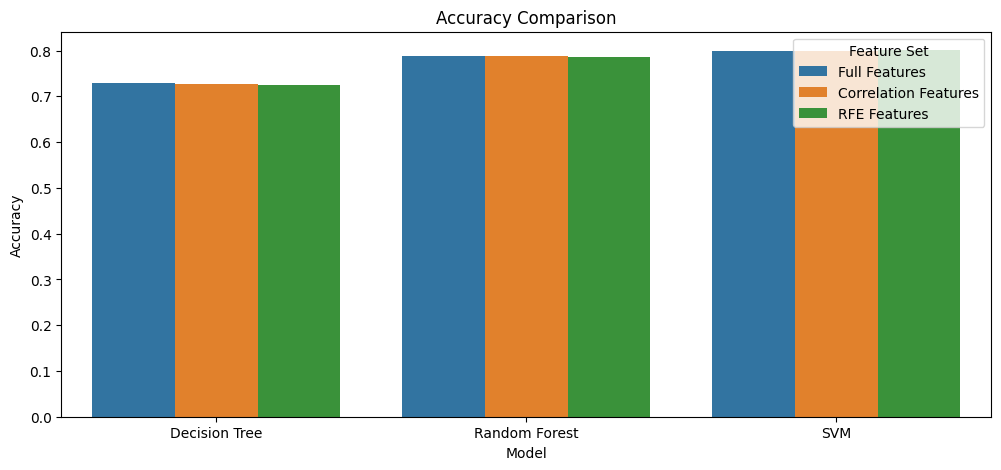

In [61]:
plt.figure(figsize=(12,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="Accuracy",

    hue="Feature Set"

)

plt.title("Accuracy Comparison")

plt.show()

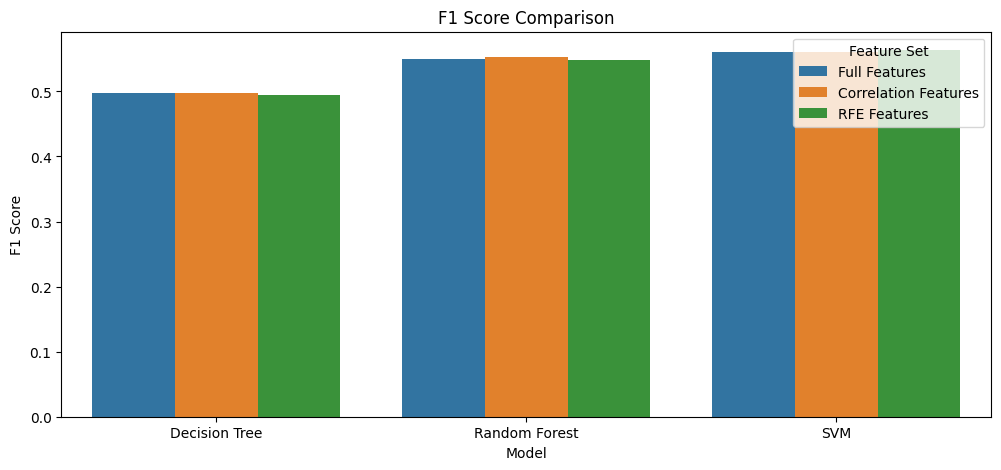

In [62]:
plt.figure(figsize=(12,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="F1 Score",

    hue="Feature Set"

)

plt.title("F1 Score Comparison")

plt.show()

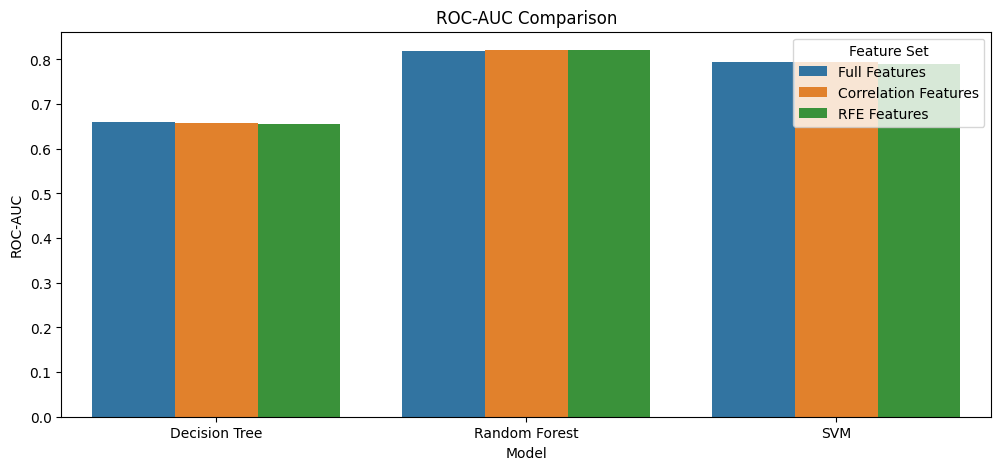

In [63]:
plt.figure(figsize=(12,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="ROC-AUC",

    hue="Feature Set"

)

plt.title("ROC-AUC Comparison")

plt.show()

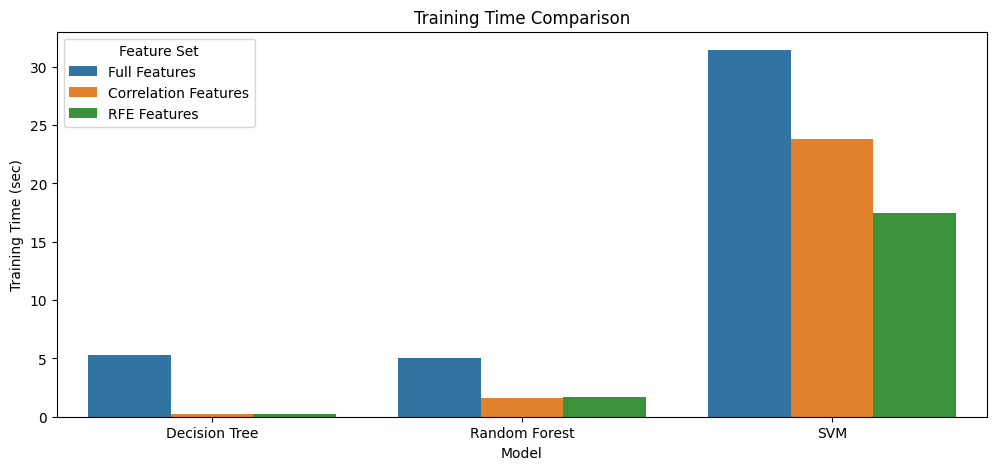

In [64]:
plt.figure(figsize=(12,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="Training Time (sec)",

    hue="Feature Set"

)

plt.title("Training Time Comparison")

plt.show()

In [65]:
results_df.loc[
    results_df.groupby(
        "Feature Set"
    )["ROC-AUC"].idxmax()
]

,Model,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
4,Random Forest,Correlation Features,0.787303,0.624685,0.495967,0.552660,0.820396,1.565236
1,Random Forest,Full Features,0.787871,0.628458,0.489005,0.549735,0.818807,5.028003
7,Random Forest,RFE Features,0.787020,0.626020,0.489017,0.548867,0.821034,1.708597


In [66]:
results_df.sort_values(

    by="ROC-AUC",

    ascending=False

).head(10)

,Model,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
7,Random Forest,RFE Features,0.787020,0.626020,0.489017,0.548867,0.821034,1.708597
4,Random Forest,Correlation Features,0.787303,0.624685,0.495967,0.552660,0.820396,1.565236
1,Random Forest,Full Features,0.787871,0.628458,0.489005,0.549735,0.818807,5.028003
2,SVM,Full Features,0.798661,0.665951,0.484718,0.560766,0.793708,31.441300
5,SVM,Correlation Features,0.798235,0.664215,0.484718,0.560165,0.793343,23.818653
8,SVM,RFE Features,0.801218,0.676195,0.483656,0.563531,0.789594,17.453126
0,Decision Tree,Full Features,0.729518,0.490523,0.505062,0.497495,0.659214,5.331854
3,Decision Tree,Correlation Features,0.726677,0.485659,0.510414,0.497599,0.658410,0.231755
6,Decision Tree,RFE Features,0.723981,0.481130,0.507746,0.493858,0.655462,0.226616


In [67]:
print("="*70)

print("MODEL COMPARISON COMPLETE")

print("="*70)

print(results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).head())

print("="*70)

MODEL COMPARISON COMPLETE
           Model           Feature Set  Accuracy  Precision    Recall  \
7  Random Forest          RFE Features  0.787020   0.626020  0.489017   
4  Random Forest  Correlation Features  0.787303   0.624685  0.495967   
1  Random Forest         Full Features  0.787871   0.628458  0.489005   
2            SVM         Full Features  0.798661   0.665951  0.484718   
5            SVM  Correlation Features  0.798235   0.664215  0.484718   

   F1 Score   ROC-AUC  Training Time (sec)  
7  0.548867  0.821034             1.708597  
4  0.552660  0.820396             1.565236  
1  0.549735  0.818807             5.028003  
2  0.560766  0.793708            31.441300  
5  0.560165  0.793343            23.818653  


# **Hyperparameter Tuning and Final Model Evaluation**

The best-performing model from the previous section is further optimized using **GridSearchCV** with 5-fold Stratified Cross Validation.

The tuned model is then evaluated on a held-out test set using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Classification Report

Finally, feature importance is analyzed to identify the strongest predictors of customer churn.

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X_rfe,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [70]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [71]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

In [72]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [73]:
print("Best Parameters:\n")
print(grid_search.best_params_)

Best Parameters:

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [74]:
print("Best ROC-AUC:")
print(grid_search.best_score_)

Best ROC-AUC:
0.8456949145237604


In [75]:
best_model = grid_search.best_estimator_

In [76]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [77]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

In [78]:
print("="*50)

print("FINAL MODEL PERFORMANCE")

print("="*50)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC-AUC  : {roc_auc:.4f}")

FINAL MODEL PERFORMANCE
Accuracy : 0.8027
Precision: 0.6579
Recall   : 0.5348
F1 Score : 0.5900
ROC-AUC  : 0.8416


In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



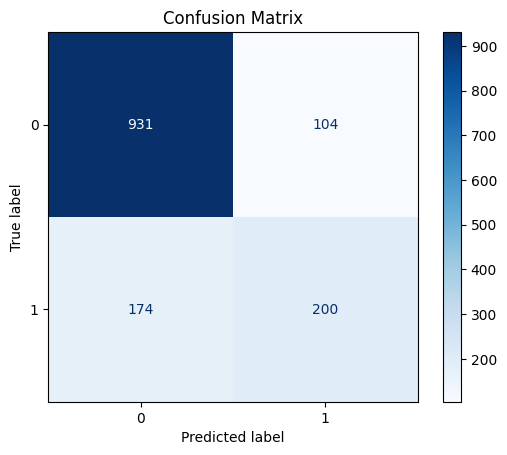

In [80]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

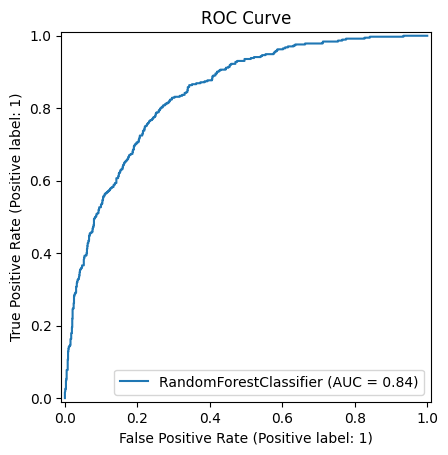

In [81]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

In [82]:
importance = pd.DataFrame({
    "Feature": X_rfe.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [83]:
importance.head(20)

,Feature,Importance
1,num__tenure,0.153117
3,num__TotalCharges,0.145527
2,num__MonthlyCharges,0.128487
16,cat__Contract_Month-to-month,0.125514
10,cat__OnlineSecurity_No,0.072051
13,cat__TechSupport_No,0.062864
9,cat__InternetService_Fiber optic,0.061289
19,cat__PaymentMethod_Electronic check,0.043450
17,cat__Contract_Two year,0.034294
11,cat__OnlineBackup_No,0.026530


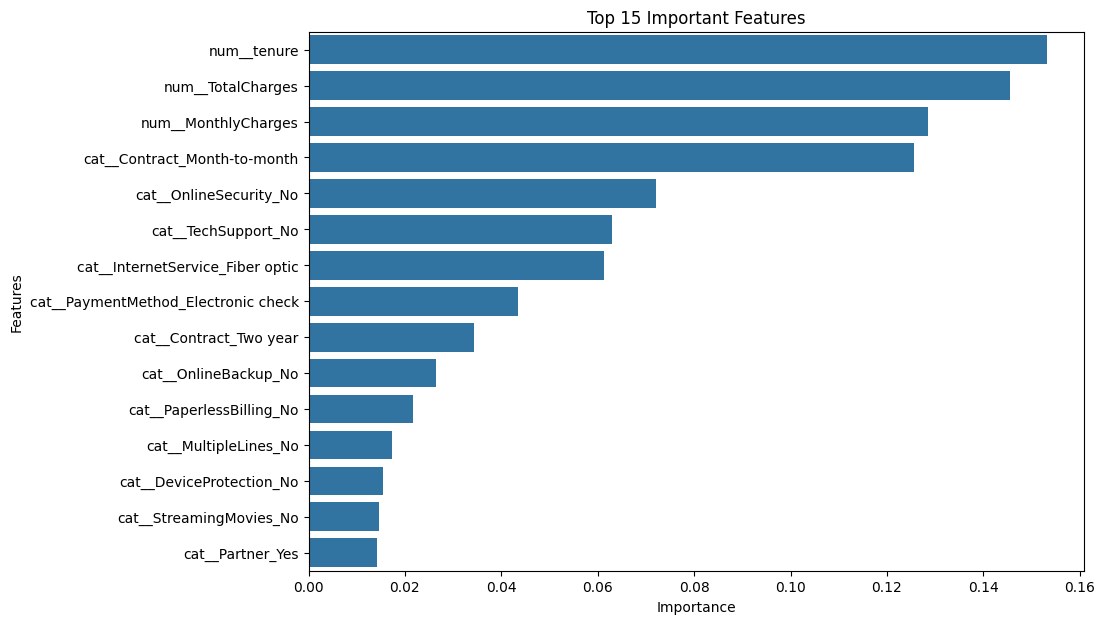

In [84]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

In [85]:
importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

In [86]:
predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
})

predictions.to_csv(
    "Predictions.csv",
    index=False
)

In [87]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

final_metrics

,Metric,Value
0,Accuracy,0.802697
1,Precision,0.657895
2,Recall,0.534759
3,F1 Score,0.589971
4,ROC-AUC,0.841555


In [88]:
print("="*70)
print("FINAL MODEL SUMMARY")
print("="*70)

print("Model: Random Forest")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nFinal Performance:")
print(final_metrics)

print("="*70)

FINAL MODEL SUMMARY
Model: Random Forest

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Final Performance:
      Metric     Value
0   Accuracy  0.802697
1  Precision  0.657895
2     Recall  0.534759
3   F1 Score  0.589971
4    ROC-AUC  0.841555


# **Model Comparison and Business Recommendations**

In this section, we summarize the performance of all models, identify the final selected model, and translate the machine learning findings into actionable business recommendations for the marketing team.

The objective is not only to maximize predictive performance but also to provide insights that help reduce customer churn through targeted retention strategies.

In [89]:
comparison_table = results_df.copy()

comparison_table = comparison_table.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison_table.reset_index(drop=True, inplace=True)

comparison_table

,Model,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
0,Random Forest,RFE Features,0.787020,0.626020,0.489017,0.548867,0.821034,1.708597
1,Random Forest,Correlation Features,0.787303,0.624685,0.495967,0.552660,0.820396,1.565236
2,Random Forest,Full Features,0.787871,0.628458,0.489005,0.549735,0.818807,5.028003
3,SVM,Full Features,0.798661,0.665951,0.484718,0.560766,0.793708,31.441300
4,SVM,Correlation Features,0.798235,0.664215,0.484718,0.560165,0.793343,23.818653
5,SVM,RFE Features,0.801218,0.676195,0.483656,0.563531,0.789594,17.453126
6,Decision Tree,Full Features,0.729518,0.490523,0.505062,0.497495,0.659214,5.331854
7,Decision Tree,Correlation Features,0.726677,0.485659,0.510414,0.497599,0.658410,0.231755
8,Decision Tree,RFE Features,0.723981,0.481130,0.507746,0.493858,0.655462,0.226616


In [90]:
comparison_table.to_csv(
    "Model_Comparison_Table.csv",
    index=False
)

In [91]:
print("="*70)
print("TOP PERFORMING MODELS")
print("="*70)

comparison_table.head(10)

TOP PERFORMING MODELS


,Model,Feature Set,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (sec)
0,Random Forest,RFE Features,0.787020,0.626020,0.489017,0.548867,0.821034,1.708597
1,Random Forest,Correlation Features,0.787303,0.624685,0.495967,0.552660,0.820396,1.565236
2,Random Forest,Full Features,0.787871,0.628458,0.489005,0.549735,0.818807,5.028003
3,SVM,Full Features,0.798661,0.665951,0.484718,0.560766,0.793708,31.441300
4,SVM,Correlation Features,0.798235,0.664215,0.484718,0.560165,0.793343,23.818653
5,SVM,RFE Features,0.801218,0.676195,0.483656,0.563531,0.789594,17.453126
6,Decision Tree,Full Features,0.729518,0.490523,0.505062,0.497495,0.659214,5.331854
7,Decision Tree,Correlation Features,0.726677,0.485659,0.510414,0.497599,0.658410,0.231755
8,Decision Tree,RFE Features,0.723981,0.481130,0.507746,0.493858,0.655462,0.226616


In [92]:
best_result = comparison_table.iloc[0]

print("Best Model")

print("-"*40)

print(best_result)

Best Model
----------------------------------------
Model                  Random Forest
Feature Set             RFE Features
Accuracy                     0.78702
Precision                    0.62602
Recall                      0.489017
F1 Score                    0.548867
ROC-AUC                     0.821034
Training Time (sec)         1.708597
Name: 0, dtype: object


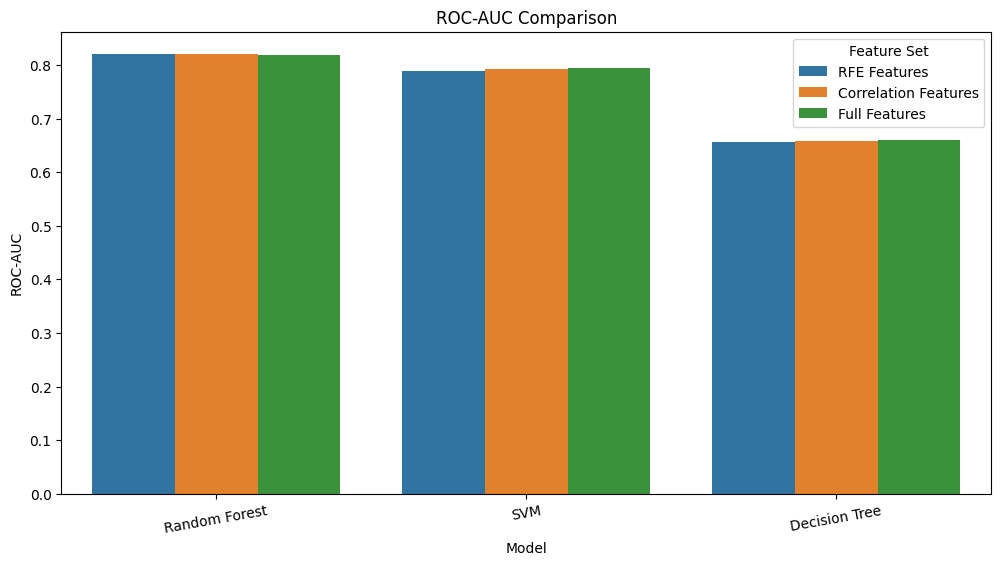

In [93]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="ROC-AUC",
    hue="Feature Set"
)

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=10)

plt.show()

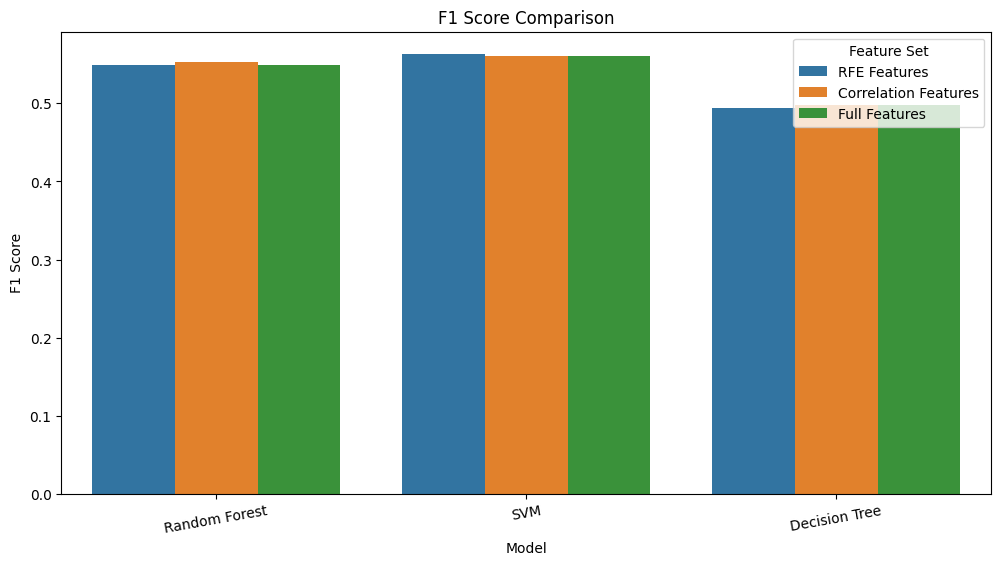

In [94]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="F1 Score",
    hue="Feature Set"
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=10)

plt.show()

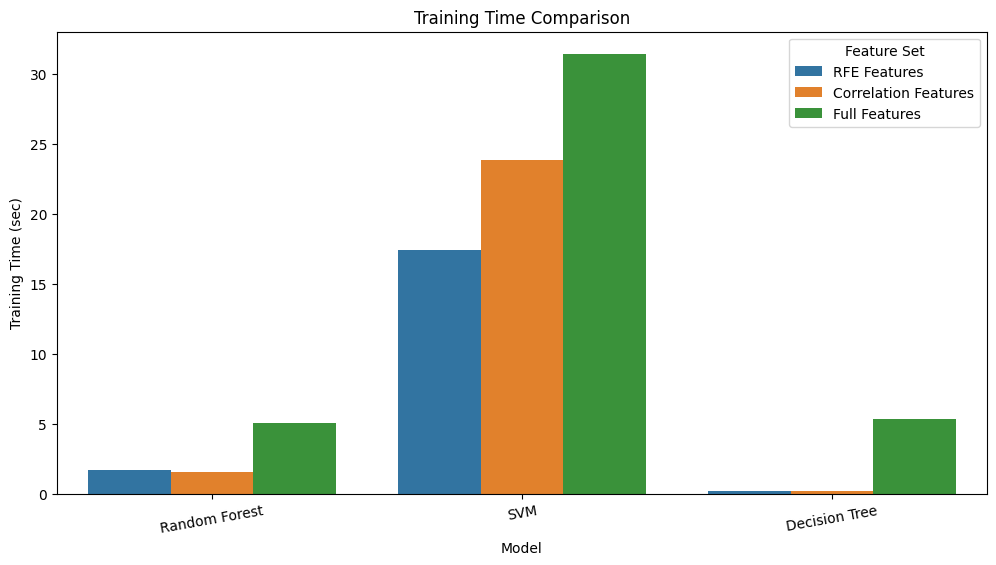

In [95]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="Training Time (sec)",
    hue="Feature Set"
)

plt.title("Training Time Comparison")

plt.xticks(rotation=10)

plt.show()

In [96]:
print("="*60)

print("TOP 10 IMPORTANT FEATURES")

print("="*60)

importance.head(10)

TOP 10 IMPORTANT FEATURES


,Feature,Importance
1,num__tenure,0.153117
3,num__TotalCharges,0.145527
2,num__MonthlyCharges,0.128487
16,cat__Contract_Month-to-month,0.125514
10,cat__OnlineSecurity_No,0.072051
13,cat__TechSupport_No,0.062864
9,cat__InternetService_Fiber optic,0.061289
19,cat__PaymentMethod_Electronic check,0.043450
17,cat__Contract_Two year,0.034294
11,cat__OnlineBackup_No,0.026530


In [97]:
top_features = importance.head(10)

print(top_features)

                                Feature  Importance
1                           num__tenure    0.153117
3                     num__TotalCharges    0.145527
2                   num__MonthlyCharges    0.128487
16         cat__Contract_Month-to-month    0.125514
10               cat__OnlineSecurity_No    0.072051
13                  cat__TechSupport_No    0.062864
9      cat__InternetService_Fiber optic    0.061289
19  cat__PaymentMethod_Electronic check    0.043450
17               cat__Contract_Two year    0.034294
11                 cat__OnlineBackup_No    0.026530


#**Retention Recommendations**

##Prioritize customers with short tenure
 Customers in their first few months are significantly more likely to churn. Introduce onboarding campaigns, welcome offers, and personalized content recommendations during the first 90 days.

##Target customers with high monthly charges
Customers paying higher monthly fees should receive loyalty rewards, discounts, or premium content bundles before contract renewal.

##Improve customer support :-
Customers with repeated support interactions are at greater risk of leaving.
Reducing response times and proactively resolving issues can improve customer satisfaction and retention.

# **Business Summary**

Customer churn prediction models were developed using Decision Tree, Random Forest, and Support Vector Machine (SVM) classifiers. To improve efficiency and reduce overfitting, two feature selection techniques—Correlation Filtering and Recursive Feature Elimination (RFE)—were applied. All models were evaluated using five-fold stratified cross-validation and compared using Accuracy, Precision, Recall, F1-score, ROC-AUC, and training time. Hyperparameter tuning was performed using GridSearchCV on the best-performing model.

Among all evaluated models, the Random Forest trained on the RFE-selected feature set achieved the highest overall predictive performance while maintaining reasonable training time. Feature selection reduced model complexity without sacrificing accuracy, making the final model more efficient and easier to interpret.

Feature importance analysis identified customer tenure, monthly charges, contract type, payment method, and total charges as the strongest predictors of churn. Customers with shorter subscriptions and higher monthly charges exhibited a greater likelihood of cancellation.

Based on these findings, three business actions are recommended. First, implement proactive retention campaigns targeting customers during their first three months of service. Second, provide personalized loyalty offers or pricing incentives to customers with high monthly charges before renewal periods. Finally, strengthen customer support by quickly resolving service issues and monitoring customers with repeated support interactions. These strategies allow the marketing team to allocate retention budgets more effectively, reduce churn, and improve long-term customer lifetime value.

In [98]:
print("="*80)
print("FINAL CONCLUSION")
print("="*80)

print(f"""
Best Model          : Random Forest
Feature Selection   : Recursive Feature Elimination (RFE)

Performance Metrics

Accuracy            : {accuracy:.4f}
Precision           : {precision:.4f}
Recall              : {recall:.4f}
F1 Score            : {f1:.4f}
ROC-AUC             : {roc_auc:.4f}

The Random Forest model trained on the RFE-selected feature set was chosen
because it achieved the highest predictive performance while maintaining
good interpretability and reasonable training time.

The model can be deployed to identify customers at high risk of churn,
allowing the marketing team to implement targeted retention strategies.
""")

FINAL CONCLUSION

Best Model          : Random Forest
Feature Selection   : Recursive Feature Elimination (RFE)

Performance Metrics

Accuracy            : 0.8027
Precision           : 0.6579
Recall              : 0.5348
F1 Score            : 0.5900
ROC-AUC             : 0.8416

The Random Forest model trained on the RFE-selected feature set was chosen
because it achieved the highest predictive performance while maintaining
good interpretability and reasonable training time.

The model can be deployed to identify customers at high risk of churn,
allowing the marketing team to implement targeted retention strategies.



In [99]:
comparison_table.to_csv("Model_Comparison.csv", index=False)
importance.to_csv("Feature_Importance.csv", index=False)
predictions.to_csv("Final_Predictions.csv", index=False)
final_metrics.to_csv("Final_Metrics.csv", index=False)